# Data Cleaning and Transformation 

## Summary, Null, and Missing Values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset 
iris = fetch_ucirepo(id=53)
X = iris.data.features 
y = iris.data.targets 

### Displays summary information from the dataset

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [4]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   150 non-null    str  
dtypes: str(1)
memory usage: 1.3 KB


&nbsp;

### Display Descriptive Statistics of the Dataset

In [5]:
X.describe(include="all")

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


&nbsp;

### Check the Number of Missing Values in Each Column

In [6]:
# this is a very clean datasets that supposed to be ready to use so there is no missing value
missing_values = X.isnull().sum()
missing_values

sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64

In [7]:
missing_values[missing_values > 0]

Series([], dtype: int64)

&nbsp;

### Checking Missing Values

In [8]:
# Again, this dataset is really clean so there is no missing values
missing_value = X.isnull().sum()
missing_value

sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64

&nbsp;

### Handling Missing Value For Numeric Feature 

In [9]:
# this is just an example, we dont actually need this for this specific dataset
less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index
over  # should be empty

Index([], dtype='str')

In [10]:
numeric_features = X[less].select_dtypes(include=['number']).columns
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())  # the key here is the fillna() function, we can assign different average like modus or mean

&nbsp;

### Handling Missing Value For Categorical Feature

In [11]:
categorical_features = X[less].select_dtypes(include=['object']).columns

for column in categorical_features:
    X[column] = X[column].fillna(X[column].mode()[0])  # unlike assigning median, .mode() return us a dataframe, with that we need a for loop to assign each value

&nbsp;

### Dropping Column With Too Many Missing Value

In [12]:
X.drop(columns=over)

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


&nbsp;

## Handling Outliers and Duplicated Data

### Cleaning Outliers

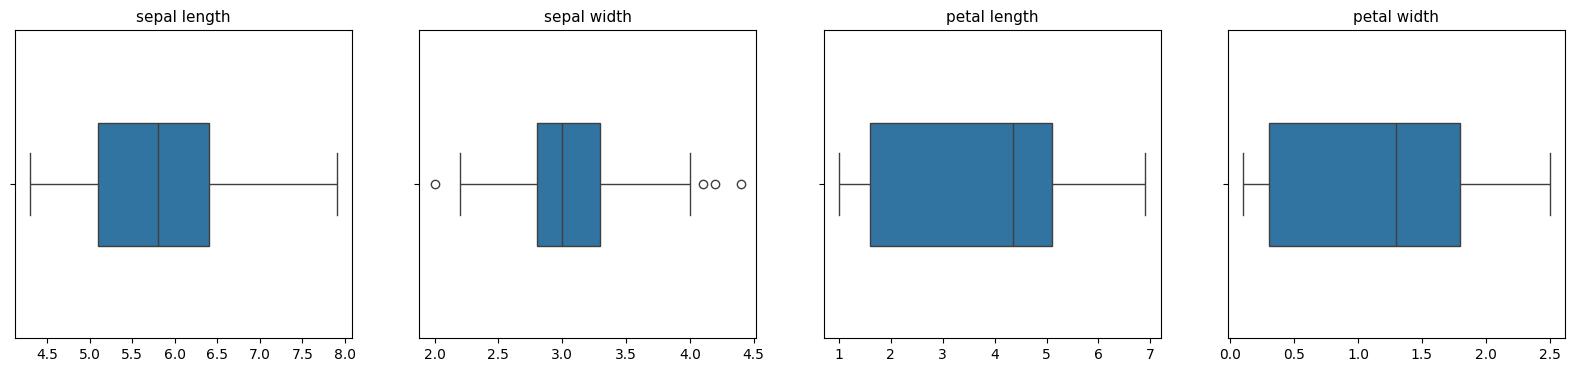

In [13]:
# Again, for this datasets outliers is should not be exist and below code only for example only

# displays boxplot for every every feature
n_features = len(numeric_features)
n_cols = min(4, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.ravel()

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(x=X[feature], ax=ax, width=0.4)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')

&nbsp;

In [14]:
# We can see some outliers on the sepal width features, but its so few that usually we're just ignore it. but for this time for demanstration purpose we still gonna try to clean it
Q1 = X[numeric_features].quantile(0.25)
Q3 = X[numeric_features].quantile(0.75)
IQR = Q3 - Q1

In [15]:
condition = ~((X[numeric_features] < (Q1 - 1.5 * IQR)) | (X[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = X.loc[condition, numeric_features]

In [16]:
categorical_features = X.select_dtypes(include=['object']).columns
X = pd.concat([df_filtered_numeric, X.loc[condition, categorical_features]], axis=1)
# i dont really know how this code above does, but its basically filter data that outside the iqr then merge it onto the prev dataframe

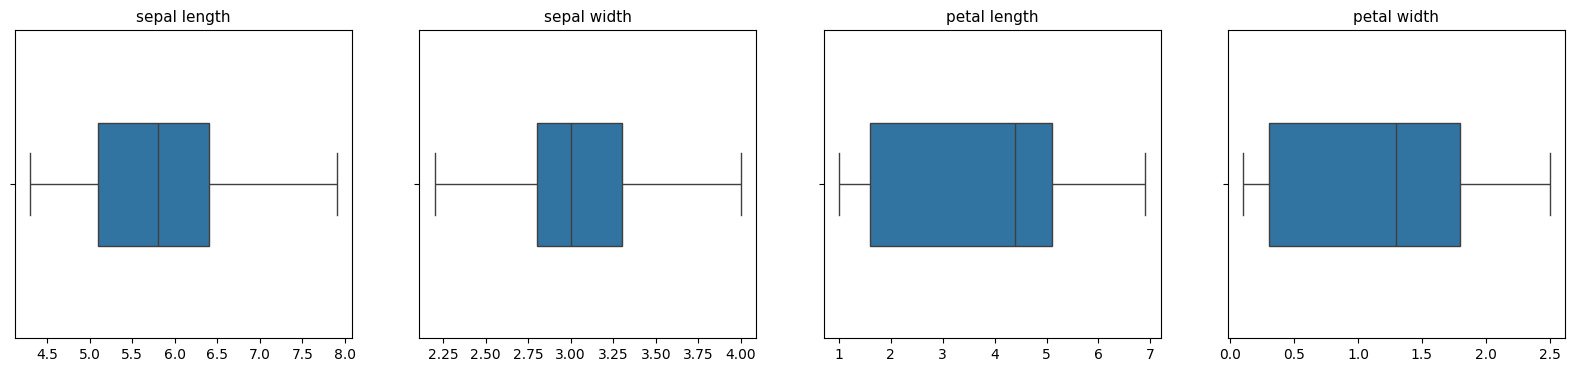

In [17]:
# displays boxplot for every every feature for comparisons
n_features = len(numeric_features)
n_cols = min(4, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.ravel()

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(x=X[feature], ax=ax, width=0.4)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')

In [18]:
# as we can see, now there is no more data outside the boundaries

&nbsp;

### Removing Duplicated Data

In [19]:
X.drop_duplicates()  # Really simple

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


&nbsp;

## Normalization and Standardization

### Normalization: Turning the Data Scale into standard

$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

### Standardization: Turning $\mu$ = $0$ and $\sigma$ = $1$
$$z = \frac{x - \mu}{\sigma}$$

In [20]:
# There is a analytical method to do this calculation, but the fastest way (for learning purpose) we can use sklearn lib
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

&nbsp;

## Converting Data Type

### One-Hot Encoding: Turn Categorical Value Into Separated Binary Column

In [21]:
category_features = X.select_dtypes(include=['object']).columns
X[category_features]
df_one_hot = pd.get_dummies(X, columns=category_features)
# we dont have cat-features on this dataset tho

&nbsp;

### Label Encoding: Turn Categorical Value Into Numerical Label

In [22]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(X)

for col in category_features:
    df_lencoder[col] = label_encoder.fit_transform(X[col])